# Analysis for PsyNamic Manuscript

## Analysis of data fetching pipeline
### PubMed Fetch Results


How many articles were retrieved from PubMed via API until 31.12.2025 (with new search string)

In [3]:
import os
import sys
sys.path.append(os.path.abspath(".."))
import pandas as pd


df = pd.read_csv("../data/pubmed_fetch_results/pubmed_results_19000101_20260530_00-03-43.csv", dtype={"pubmed_id": str})
print(f'Total articles retrieved: {len(df)}')
# check if there are any duplicates in the new pubmed fetch results based on pubmed_id
duplicates_pubmed_id = df[df.duplicated(subset=['pubmed_id'], keep=False)]
print(f'Number of duplicate articles in new pubmed fetch results based on pubmed_id: {len(duplicates_pubmed_id)}')

df_2025_pubmed_fetch_new_string = df[df["entrez_year"] < 2026]
print(f'Total articles retrieved until 2025: {len(df_2025_pubmed_fetch_new_string)}')
print(f'Total articles without abstract until 2025: {len(df_2025_pubmed_fetch_new_string[df_2025_pubmed_fetch_new_string["abstract"].isna()])}')


Total articles retrieved: 21530
Number of duplicate articles in new pubmed fetch results based on pubmed_id: 0
Total articles retrieved until 2025: 20801
Total articles without abstract until 2025: 4875


How many articles were retrieved from PubMed via API in 2026 (with old search string)

In [4]:
df = pd.read_csv("../data/pubmed_fetch_results/pubmed_results_20240105_20260320_00-00-10.csv", dtype={"pubmed_id": str})

print(f'Total articles retrieved: {len(df)}')
# check if there are any duplicates in the new pubmed fetch results based on pubmed_id
duplicates_pubmed_id = df[df.duplicated(subset=['pubmed_id'], keep=False)]
print(f'Number of duplicate articles in new pubmed fetch results based on pubmed_id: {len(duplicates_pubmed_id)}')

df_2025_pubmed_fetch = df[df["entrez_year"] < 2026]
print(f'Total articles retrieved until 2025: {len(df_2025_pubmed_fetch)}')
print(f'Total articles without abstract until 2025: {len(df_2025_pubmed_fetch[df_2025_pubmed_fetch["abstract"].isna()])}')


FileNotFoundError: [Errno 2] No such file or directory: '../data/pubmed_fetch_results/pubmed_results_20240105_20260320_00-00-10.csv'

In [ ]:
df_2026_pubmed_fetch = df[df["entrez_year"] == 2026]
print(f'Total articles retrieved in 2026: {len(df_2026_pubmed_fetch)}')
print(f'Total articles without abstract in 2026: {len(df_2026_pubmed_fetch[df_2026_pubmed_fetch["abstract"].isna()])}')

Total articles retrieved in 2026: 151
Total articles without abstract in 2026: 1


In [ ]:
# from data.get_pubmed_data import get_pubmed_id_from_title
# from tqdm import tqdm


# as_file = "../data/manual/as_review_studies_relevant_with_info_20240101_00-00-00.csv"
# df_as_relevant = pd.read_csv(as_file)
# # count how many articles don't have a pubmed_id
# num_missing_pubmed_id = df_as_relevant['pubmed_id'].isna().sum()
# print(f'Number of articles in ASreview dataset without pubmed_id: {num_missing_pubmed_id}')


# # improve pubmedid matching
# for idx, row in tqdm(df_as_relevant.iterrows(), total=len(df_as_relevant)):
#     pubmed_id = row['pubmed_id']
#     if pd.isna(pubmed_id):
#         pubmed_id = get_pubmed_id_from_title(row['title'])
#         if pubmed_id:
#             df_as_relevant.at[idx, 'pubmed_id'] = pubmed_id
#             df_as_relevant.at[idx, 'pubmed_url'] = f'https://pubmed.ncbi.nlm.nih.gov/{pubmed_id}/'

# # check again how many articles don't have a pubmed_id
# num_missing_pubmed_id = df_as_relevant['pubmed_id'].isna().sum()
# print(f'Number of articles in ASreview dataset without pubmed_id after matching: {num_missing_pubmed_id}')

# # write back to csv
# df_as_relevant.to_csv("../data/manual/as_review_studies_relevant_with_info_20240101_00-00-00.csv", index=False)




In [ ]:
as_file = "../data/manual/as_review_studies_relevant_with_info_20240101_00-00-00.csv"
df_as_relevant = pd.read_csv(as_file)
# convert pubmed_id to from float to int and then to string, while keeping NaN values as is
df_as_relevant['pubmed_id'] = df_as_relevant['pubmed_id'].apply(lambda x: str(int(x)) if pd.notna(x) else x)    

duplicates_as_relevant_pubmed_id = df_as_relevant[df_as_relevant.duplicated(subset=['pubmed_id'], keep=False)]
print(f'Number of duplicate articles in ASreview dataset based on pubmed_id: {len(duplicates_as_relevant_pubmed_id)}')

# print sorted duplicates (title + pubmedId) based on pubmed_id, where pubmed_id is not null
print(duplicates_as_relevant_pubmed_id.sort_values(by="pubmed_id")[["title", "pubmed_id"]].dropna())


Number of duplicate articles in ASreview dataset based on pubmed_id: 925
                                                  title pubmed_id
162   Psilocybin can occasion mystical-type experien...  16826400
165   Psilocybin can occasion mystical-type experien...  16826400
2117  Effects of nicotine on the neurophysiological ...  24478731
2119  Effects of nicotine on the neurophysiological ...  24478731
34    LSD Acutely Impairs Fear Recognition and Enhan...  27249781
52    LSD acutely impairs fear recognition and enhan...  27249781
808   Ketamine for treatment of mood disorders and s...  35166663
812   Ketamine for treatment of mood disorders and s...  35166663


Are there any duplicates in the 2025 PubMed API data? Or in the ASreview retrieved dataset?

In [ ]:
mask = df_as_relevant['pubmed_id'].notna()

duplicates = df_as_relevant[
    mask &
    df_as_relevant.duplicated(subset=['pubmed_id'], keep=False)
]

print(f"Number of duplicate articles in ASreview dataset (excluding NaN): {len(duplicates)}")
duplicates_no_nan = df_2025_pubmed_fetch[df_2025_pubmed_fetch.duplicated(subset=['pubmed_id'], keep=False) & df_2025_pubmed_fetch['pubmed_id'].notnull()]
print(f'Number of duplicate articles in 2025 PubMed API dataset: {len(duplicates_no_nan)}')

duplicates_new_string = df_2025_pubmed_fetch_new_string[df_2025_pubmed_fetch_new_string.duplicated(subset=['pubmed_id'], keep=False)]
print(f'Number of duplicate articles in 2025 PubMed API dataset with new string: {len(duplicates_new_string)}')


Number of duplicate articles in ASreview dataset (excluding NaN): 8
Number of duplicate articles in 2025 PubMed API dataset: 0
Number of duplicate articles in 2025 PubMed API dataset with new string: 0


### Relevant Studies from PubMed API
How many articles were classified relevant from PubMed API data until 31.12.2025 (old string)?

In [ ]:
df_rel = pd.read_csv("../data/relevant_studies/studies_20260320_00-09-37.csv")
df_rel_2025 = df_rel[df_rel["entrez_year"] <= 2025]
print(f'Total articles until 2025: {len(df_rel_2025)}')
df_rel_2025_incl = df_rel_2025[df_rel_2025["prediction"] == 1]
print(f'Total articles classified relevant until 2025: {len(df_rel_2025_incl)}')
print(f'Total articles classified irrelevant until 2025: {len(df_rel_2025[df_rel_2025["prediction"] == 0])}')


Total articles until 2025: 1157
Total articles classified relevant until 2025: 634
Total articles classified irrelevant until 2025: 523


How many articles were classified relevant from PubMed API data until 31.12.2025 (new string)?

In [ ]:
df_rel_new_string = pd.read_csv('../data/manual/studies_20260530_02-04-42.csv', dtype={"pubmed_id": str})
df_rel_2025_new = df_rel_new_string[df_rel_new_string["entrez_year"] <= 2025]
df_rel_2025_new_incl = df_rel_2025_new[df_rel_2025_new["prediction"] == 1]
df_rel_2025_new_excl = df_rel_2025_new[df_rel_2025_new["prediction"] == 0]
print(f'Total articles classified relevant until 2025: {len(df_rel_2025_new_incl)}')
print(f'Total articles classified irrelevant until 2025: {len(df_rel_2025_new_excl)}')

Total articles classified relevant until 2025: 4571
Total articles classified irrelevant until 2025: 11355


Are there any samples determined as relevant from new Pubmed search which were manually determined as irrelevant (not irrelevant after stopping criteria)? (action required, remove them from merged database)

In [ ]:
# from tqdm import tqdm

# def read_in_asreview() -> list[pd.DataFrame]:
#     input_file = "/home/veral/PsyNamic/data/raw_data/asreview_dataset_all_Psychedelic Study.csv"
#     df = pd.read_csv(input_file)
#     df['title'] = df['title'].str.lower()
#     included = df[df['included'] == 1]
#     excluded = df[df['included'] == 0]
#     excluded_after_stopping = df[df['included'].isna()]

#     return [included, excluded, excluded_after_stopping, df]

# _, excluded, excluded_after_stopping, _ = read_in_asreview()
# excluded['pubmed_id'] = None
# for idx, row in tqdm(excluded.iterrows(), total=len(excluded)):
#     title = row['title']
#     pubmed_id = get_pubmed_id_from_title(title)
#     excluded.at[idx, 'pubmed_id'] = pubmed_id

# excluded.to_csv("../data/manual/excluded_with_pubmed_id.csv", index=False)

# for idx, row in tqdm(excluded_after_stopping.iterrows(), total=len(excluded_after_stopping)):
#     title = row['title']
#     pubmed_id = get_pubmed_id_from_title(title)
#     excluded_after_stopping.at[idx, 'pubmed_id'] = pubmed_id

# excluded_after_stopping.to_csv("../data/manual/excluded_after_stopping_with_pubmed_id.csv", index=False)  



Number of overlaps between ASReview included and irrelevant studies until 2025 (pubmed_id): 126
Number of overlaps between ASReview included and relevant studies until 2025 (pubmed_id): 2126


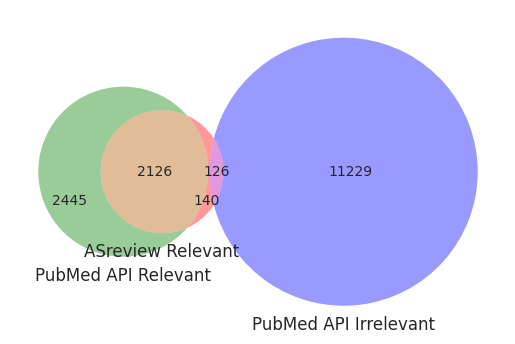

In [ ]:
from analysis import compare_dfs
from matplotlib_venn import venn3


excluded = pd.read_csv("../data/manual/as_review_studies_excluded_with_pubmed_id.csv", dtype={"pubmed_id": str})
excluded_after_stopping = pd.read_csv("../data/manual/as_review_studies_excluded_after_stopping_with_pubmed_id.csv", dtype={"pubmed_id": str})



nr, matches = compare_dfs(df_as_relevant, df_rel_2025_new_excl, ['pubmed_id'], ['pubmed_id'])
print(f'Number of overlaps between ASReview included and irrelevant studies until 2025 (pubmed_id): {nr}')
nr, matches = compare_dfs(df_as_relevant, df_rel_2025_new_incl, ['pubmed_id'], ['pubmed_id'])
print(f'Number of overlaps between ASReview included and relevant studies until 2025 (pubmed_id): {nr}')

sets = [
    set(df_as_relevant['pubmed_id'].dropna()),
    set(df_rel_2025_new_incl['pubmed_id'].dropna()),
    set(df_rel_2025_new_excl['pubmed_id'].dropna()),

]
v = venn3(sets,    
      ['ASreview Relevant', 'PubMed API Relevant', 'PubMed API Irrelevant'])

# move 3. and 4. label down
v.get_label_by_id('100').set_y(-0.1)
v.get_label_by_id('010').set_y(-0.1)

Number of overlaps between ASReview excluded and relevant studies until 2025 (pubmed_id): 41
Number of overlaps between ASReview excluded after stopping and relevant studies until 2025 (pubmed_id): 63


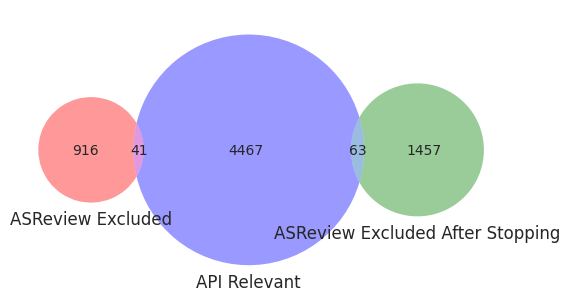

In [ ]:
nr, matches_excluded = compare_dfs(excluded, df_rel_2025_new_incl, ['pubmed_id'], ['pubmed_id'])
print(f'Number of overlaps between ASReview excluded and relevant studies until 2025 (pubmed_id): {nr}')

nr, matches_excluded_after_stopping = compare_dfs(excluded_after_stopping, df_rel_2025_new_incl, ['pubmed_id'], ['pubmed_id'])
print(f'Number of overlaps between ASReview excluded after stopping and relevant studies until 2025 (pubmed_id): {nr}')

sets = [
    set(excluded['pubmed_id'].dropna()),
    set(excluded_after_stopping['pubmed_id'].dropna()),
    set(df_rel_2025_new_incl['pubmed_id'].dropna())
]
venn3(sets, ['ASReview Excluded', 'ASReview Excluded After Stopping', 'API Relevant'])


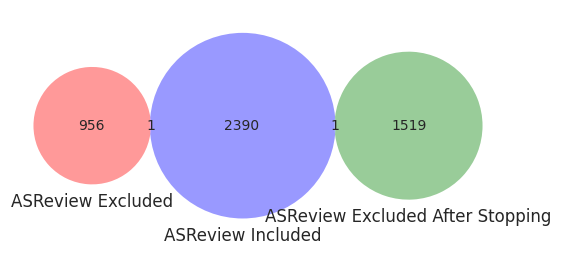

In [ ]:
sets = [
    set(excluded['pubmed_id'].dropna()),
    set(excluded_after_stopping['pubmed_id'].dropna()),
    set(df_as_relevant['pubmed_id'].dropna())
]

venn3(sets, ['ASReview Excluded', 'ASReview Excluded After Stopping', 'ASReview Included'])

How many articles from classified as relevant from PubMed API data until 31.12.2025 (new string) which are in the ASReview included dataset?

In [ ]:
nr, matches = compare_dfs(df_as_relevant, df_rel_2025_new_incl, ['pubmed_id'], ['pubmed_id'])
print(f'Number of overlaps between ASReview included and relevant studies until 2025 (pubmed_id): {nr}')
print(matches["pubmed_id_df1"].nunique())
vc = matches["pubmed_id_df1"].value_counts()


duplicated_ids = vc[vc > 1]
print(duplicated_ids)

Number of overlaps between ASReview included and relevant studies until 2025 (pubmed_id): 2126
2126
pubmed_id_df1
27249781    2
16826400    2
35166663    2
Name: count, dtype: int64


How many articles of the api results with the new search string were already included in the dataset of the old search string?

In [ ]:
nr, matches = compare_dfs(df_rel_2025_incl, df_rel_2025_new_incl, ['pubmed_id'], ['pubmed_id'])
print(f'Number of overlaps between relevant studies until 2025 with old and new string (pubmed_id): {nr}')

Number of overlaps between relevant studies until 2025 with old and new string (pubmed_id): 628


Are there any sample determined as not relevant from new Pubmed search which were manually determined as relevant? (no action required because they are in AS database)

In [ ]:
nr, matches = compare_dfs(df_rel_2025_new_excl, df_as_relevant, ['pubmed_id'], ['pubmed_id'])
print(f'Number of overlaps between ASReview excluded and relevant studies until 2025 (pubmed_id): {nr}')

Number of overlaps between ASReview excluded and relevant studies until 2025 (pubmed_id): 126


### Total relevant studies up until 31.12.2025


In [ ]:
# ------------------------------------------------------------------
# Summary of input datasets
# ------------------------------------------------------------------

print("\n=== INPUT DATASETS ===")
print(f"ASReview relevant articles:           {len(df_as_relevant):,}")
print(f"PubMed API relevant articles (2025):  {len(df_rel_2025_new_incl):,}")

# ------------------------------------------------------------------
# Define exclusion sets
# ------------------------------------------------------------------

excluded_ids = set(excluded["pubmed_id"].dropna())
excluded_after_stopping_ids = set(excluded_after_stopping["pubmed_id"].dropna())
all_excluded_ids = excluded_ids | excluded_after_stopping_ids

asreview_ids = set(df_as_relevant["pubmed_id"].dropna())

print("\n=== EXCLUSION SETS ===")
print(f"Excluded articles:                    {len(excluded_ids):,}")
print(f"Excluded after stopping:              {len(excluded_after_stopping_ids):,}")
print(f"Total unique excluded PubMed IDs:     {len(all_excluded_ids):,}")


=== INPUT DATASETS ===
ASReview relevant articles:           3,313
PubMed API relevant articles (2025):  4,571

=== EXCLUSION SETS ===
Excluded articles:                    957
Excluded after stopping:              1,520
Total unique excluded PubMed IDs:     2,477


In [ ]:

df_v1 = df_rel_2025_new_incl.copy()

# --------------------------------------------------
# STEP 1: remove ASReview overlap
# --------------------------------------------------
overlap_asreview = set(df_v1["pubmed_id"].dropna()) & asreview_ids

df_v1_1 = df_v1[~df_v1["pubmed_id"].isin(overlap_asreview)].copy()

print("STEP 1: Remove ASReview overlap")
print(f"Overlap removed: {len(overlap_asreview):,}")
print(f"Remaining:       {len(df_v1_1):,}")

# --------------------------------------------------
# STEP 2: remove excluded IDs
# --------------------------------------------------
overlap_excluded = set(df_v1_1["pubmed_id"].dropna()) & all_excluded_ids

df_v1_final = df_v1_1[~df_v1_1["pubmed_id"].isin(all_excluded_ids)].copy()

print("\nSTEP 2: Remove excluded IDs")
print(f"Excluded removed: {len(overlap_excluded):,}")
print(f"Remaining:        {len(df_v1_final):,}")

# --------------------------------------------------
# MERGE
# --------------------------------------------------
merged_v1 = pd.concat([df_as_relevant, df_v1_final], ignore_index=True)

print("\nFINAL RESULT (VARIANT 1)")
print(f"PubMed final: {len(df_v1_final):,}")
print(f"ASReview:    {len(df_as_relevant):,}")
print(f"Merged:      {len(merged_v1):,}")

STEP 1: Remove ASReview overlap
Overlap removed: 2,126
Remaining:       2,445

STEP 2: Remove excluded IDs
Excluded removed: 103
Remaining:        2,342

FINAL RESULT (VARIANT 1)
PubMed final: 2,342
ASReview:    3,313
Merged:      5,655


In [ ]:
df_v2 = df_rel_2025_new_incl.copy()

# --------------------------------------------------
# STEP 1: remove excluded IDs
# --------------------------------------------------
overlap_excluded = set(df_v2["pubmed_id"].dropna()) & all_excluded_ids

df_v2_1 = df_v2[~df_v2["pubmed_id"].isin(all_excluded_ids)].copy()

print("STEP 1: Remove excluded IDs")
print(f"Excluded removed: {len(overlap_excluded):,}")
print(f"Remaining:        {len(df_v2_1):,}")

# --------------------------------------------------
# STEP 2: remove ASReview overlap
# --------------------------------------------------
overlap_asreview = set(df_v2_1["pubmed_id"].dropna()) & asreview_ids

df_v2_final = df_v2_1[~df_v2_1["pubmed_id"].isin(overlap_asreview)].copy()

print("\nSTEP 2: Remove ASReview overlap")
print(f"Overlap removed: {len(overlap_asreview):,}")
print(f"Remaining:       {len(df_v2_final):,}")

# --------------------------------------------------
# MERGE
# --------------------------------------------------
merged_v2 = pd.concat([df_as_relevant, df_v2_final], ignore_index=True)

print("\nFINAL RESULT (VARIANT 2)")
print(f"PubMed final: {len(df_v2_final):,}")
print(f"ASReview:    {len(df_as_relevant):,}")
print(f"Merged:      {len(merged_v2):,}")


STEP 1: Remove excluded IDs
Excluded removed: 104
Remaining:        4,467

STEP 2: Remove ASReview overlap
Overlap removed: 2,125
Remaining:       2,342

FINAL RESULT (VARIANT 2)
PubMed final: 2,342
ASReview:    3,313
Merged:      5,655


Are there duplicates in merged dataset?

In [ ]:
# Remove duplicates based on pubmed_id, but only for non-null/empty pubmed_ids
mask = merged_v2['pubmed_id'].notna() & (merged_v2['pubmed_id'] != "")
nr_duplicates = merged_v2[mask]['pubmed_id'].duplicated().sum()
print(f"Number of duplicate pubmed_ids in ASReview relevant dataset: {nr_duplicates}")
merged_v2 = pd.concat([
    merged_v2[~mask],  # keep NaN / empty pubmed_id rows
    merged_v2[mask].drop_duplicates(subset=['pubmed_id'], keep='first')
], ignore_index=True)
print(len(merged_v2))

# check how many duplicates are in merged_df based on same title and year, not considerin year NaN
duplicates_merged = merged_v2[merged_v2.duplicated(subset=['title', 'year'], keep=False) & merged_v2['year'].notna()]
print(f'Number of duplicate articles in merged dataset based on title and year: {len(duplicates_merged)}')
# print those duplicates
print(duplicates_merged[['id', 'title', 'year', 'pubmed_id']])


# check how many duplicates based on title only
duplicates_title = merged_v2[merged_v2.duplicated(subset=['title'], keep=False)]
print(f'Number of duplicate articles in merged dataset based on title only: {len(duplicates_title)}')
print(duplicates_title[['id', 'title', 'year', 'pubmed_id']])

# write duplicates to csv
duplicates_title.to_csv("../analysis/duplicates_title.csv", index=False)

Number of duplicate pubmed_ids in ASReview relevant dataset: 4
5651
Number of duplicate articles in merged dataset based on title and year: 2
       id                                              title    year pubmed_id
234  8180  Relationship of ketamine's antidepressant and ...  2013.0       NaN
256  8179  Relationship of ketamine's antidepressant and ...  2013.0       NaN
Number of duplicate articles in merged dataset based on title only: 20
            id                                              title    year  \
141       2387  A Study of the Efficacy and Safety of Intranas...  2017.0   
142       2398  A Study of the Efficacy and Safety of Intranas...  2018.0   
234       8180  Relationship of ketamine's antidepressant and ...  2013.0   
235       5122  Do the dissociative side effects of ketamine m...  2014.0   
256       8179  Relationship of ketamine's antidepressant and ...  2013.0   
432       4631  Cortisol levels and MDMA-induced memory impair...  2012.0   
433       4

Do the numbers add up to the PsyNamic Webapp dashboard?

In [ ]:
df_rel_2026_new = df_rel_new_string[
    (df_rel_new_string["entrez_year"] > 2025) &
    (df_rel_new_string["prediction"] == 1)
]
print(f'Total articles classified relevant in 2026: {len(df_rel_2026_new)}')

len(merged_v2)+len(df_rel_2026_new)

Total articles classified relevant in 2026: 245


5896

Write the filtered up to 2025 plus the 2026 relevant articles in a new csv file.

In [ ]:
rel_api_2026 = pd.concat([df_v2_final, df_rel_2026_new], ignore_index=True)
print(f'Total relevant articles in 2026: {len(df_rel_2026_new)}')
print(f'Total relevant articles in 2026 (including those from 2025): {len(rel_api_2026)}')

rel_api_2026.to_csv("../data/manual/studies_relevant_deduplicated_excluded_20260530_00-00-00.csv", index=False)

Total relevant articles in 2026: 245
Total relevant articles in 2026 (including those from 2025): 2587


## Analysis of predictions
### Classification predictions

In [ ]:
merged_df = merged_v2.copy()
merged_df.head()

,id,text,type_of_reference,name_of_database,number,keywords,language,notes,year,start_page,...,asreview_prior,exported_notes_1,included,asreview_ranking,pubmed_url,pubmed_id,prediction,probability,pub_date,entrez_year
0,6152,Ketamine Versus Midazolam for Recurrence of Su...,JOUR,NaN,NaN,"['Depression', 'Ketamine', 'Midazolam', 'Recur...",NaN,[],2020.0,NaN,...,1.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,7738,Acute autonomic and psychotropic effects of LS...,JOUR,NaN,4,"['*European', '*controlled study', '*human', '...",NaN,[],2015.0,359,...,0.0,NaN,1.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN
2,4967,"Autonomic, cardiovascular, and endocrine effec...",JOUR,NaN,NaN,"['*human', '*lysergide', '*normal human', 'Adr...",NaN,[],2015.0,187,...,0.0,NaN,1.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2105,Acute dose-response effects of LSD in healthy ...,JOUR,NaN,NaN,"['*dose response', '*lysergide', 'Adult', 'Anx...",NaN,[],2016.0,S248‐S249,...,0.0,NaN,1.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN
4,4961,Acute effects of LSD in healthy subjects and i...,JOUR,NaN,NaN,"['*psychotherapy', 'Adult', 'Altered state of ...",NaN,[],2019.0,75,...,0.0,NaN,1.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
class_data = pd.read_csv("../analysis/export/classification_data.csv")
ner_data = pd.read_csv("../analysis/export/ner_data.csv")
dosage_ner_data = pd.read_csv("../analysis/export/dosage_data.csv")
study_data = pd.read_csv("../analysis/export/study_data.csv")

# check if all ids of merged_df are in study_data
ids_merged = set(merged_df['id'].tolist())
ids_study_data = set(study_data['study_id'].tolist())
ids_not_in_study_data = ids_merged - ids_study_data
print(f'Number of ids in merged dataset that are not in study_data: {len(ids_not_in_study_data)}')
print(f'Number of ids in study_data that are not in merged dataset: {len(ids_study_data - ids_merged)}')

# Only keep rows in study_data where study_id is in merged_df
study_data_2025 = study_data[study_data['study_id'].isin(ids_merged)].reset_index(drop=True)
print(len(study_data_2025))

class_data_2025 = class_data[class_data['study_id'].isin(ids_merged)].reset_index(drop=True)
ner_data_2025 = ner_data[ner_data['study_id'].isin(ids_merged)].reset_index(drop=True)
dosage_ner_data_2025 = dosage_ner_data[dosage_ner_data['Study_ID'].isin(ids_merged)].reset_index(drop=True)


Number of ids in merged dataset that are not in study_data: 0
Number of ids in study_data that are not in merged dataset: 245
5651


In [ ]:
class_data_2025.head()

,study_id,task,label,probability,model,is_multilabel
0,305,Condition,Psychiatric condition,1.0,manual_annotation,True
1,305,Condition,Depression,1.0,manual_annotation,True
2,777,Condition,Psychiatric condition,1.0,manual_annotation,True
3,777,Condition,Depression,1.0,manual_annotation,True
4,1240,Condition,Psychiatric condition,1.0,manual_annotation,True


#### Clean some data anomalies
- Study Type: 3 articles with several study type in manually annotated dataset (artefact from Study Type being modelled as multilabel initially)
- Data Type

In [ ]:
study_type_df = class_data_2025[
    class_data_2025["task"] == "Study Type"
]

study_label_counts = (
    study_type_df.groupby("study_id")["label"]
    .nunique()
)

multi_label_study_ids = study_label_counts[study_label_counts > 1].index
# print these rows
print(study_type_df[study_type_df["study_id"].isin(multi_label_study_ids)].sort_values(by="study_id")[["study_id", "label"]])

# Remove "Other" and "Study Protocol" only when another Study Type exists
mask_remove = (
    class_data_2025["study_id"].isin(multi_label_study_ids)
    & class_data_2025["task"].eq("Study Type")
    & class_data_2025["label"].str.strip().str.lower().isin(
        ["other", "study protocol"]
    )
)

df = class_data_2025[~mask_remove].copy()

      study_id                              label
8827       692  Randomized-controlled trial (RCT)
8828       692                              Other


In [ ]:
study_type_df = df[
    df["task"] == "Data Type"
]

study_label_counts = (
    study_type_df.groupby("study_id")["label"]
    .nunique()
)

multi_label_study_ids = study_label_counts[study_label_counts > 1].index
print(len(multi_label_study_ids))
# print these rows
print(df[
    df["study_id"].isin(multi_label_study_ids)
    & df["task"].eq("Data Type")
])

# remove "Unknown" or "Not Applicable" when another Data Type exists
mask_remove = (
    df["study_id"].isin(multi_label_study_ids)
    & df["task"].eq("Data Type")
    & df["label"].str.strip().str.lower().isin(
        ["unknown", "not applicable"]
    )
    )

df = df[~mask_remove].copy()

0
Empty DataFrame
Columns: [study_id, task, label, probability, model, is_multilabel]
Index: []


In [ ]:
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import seaborn as sns
import numpy as np
import pandas as pd
from style.colors import GREY, BROWN, BLUE

SKIP_TASKS = ['Clinical Trial Phase', 'Study Conclusion']

TASK_ORDER_GROUP = [
    ['Study Type', 'Data Type', 'Data Collection', 'Number of Participants', 'Sex of Participants', 'Age of Participants', 'Study Purpose', 'Study Control'],
    ['Substances', 'Application Form', 'Regimen', 'Setting', 'Substance Naivety'],
    ['Condition', 'Outcomes']
]

GROUPS = ['Study characteristics', 'Substances','Clinical Measures']


def build_pallette(task, labels_list):
    
    palette = {}
    if 'Unknown' in labels_list:
        palette['Unknown'] = mcolors.to_hex(GREY)
    if 'Not applicable' in labels_list:
        palette['Not applicable'] = mcolors.to_hex(BROWN)
    if 'Other' in labels_list:
        palette['Other'] = mcolors.to_hex(BLUE)
    
    remaining_labels = [l for l in labels_list if l not in palette]

    sns_palette = (
        sns.color_palette("hls", len(remaining_labels))
        if len(remaining_labels) > 10
        else sns.color_palette("tab10", len(remaining_labels))
    )

    for color, lbl in zip(sns_palette, remaining_labels):
        palette[lbl] = mcolors.to_hex(color)
    return palette


def stacked_bar_plot(
    df,
    group_name,
    group_tasks,
    skip_tasks=None,
    shared_x=True,
    outdir: str = None,
    merge_dict: dict = None,
    title_y: float = 0.98
):
    if skip_tasks is None:
        skip_tasks = []

    df = df.copy()

    df.loc[
        (df["task"] == "Setting") & (df["label"] == "Party setting"),
        "label"
    ] = "Recreational"

    if merge_dict:
        for task, repl_dict in merge_dict.items():
            for new_label, old_labels in repl_dict.items():
                df.loc[
                    (df["task"] == task) & (df["label"].isin(old_labels)),
                    "label"
                ] = new_label

    group_tasks = [t for t in group_tasks if t not in skip_tasks]
    df = df[df["task"].isin(group_tasks)]

    if df.empty:
        return

    label_counts = (
        df.groupby(["task", "label"])["study_id"]
        .nunique()
        .reset_index(name="count")
    )

    total_nr_studies = df["study_id"].nunique()

    task_totals = (
        label_counts.groupby("task")["count"]
        .sum()
        .reset_index(name="total")
    )

    label_counts = label_counts.merge(task_totals, on="task")
    label_counts["percent"] = (
        label_counts["count"] / total_nr_studies * 100
    ).round(1)

    group_tasks_present = [
        t for t in group_tasks
        if t in label_counts["task"].unique()
    ]

    n_tasks_group = len(group_tasks_present)

    if n_tasks_group == 0:
        return

    max_total = label_counts["total"].max()

    fig, axes = plt.subplots(
        n_tasks_group,
        1,
        figsize=(12, 2.5 * n_tasks_group),
        sharex=shared_x,
        gridspec_kw={"hspace": 0.5}
    )

    if n_tasks_group == 1:
        axes = [axes]

    SMALL_THR = 350
    TINY_THR = 50

    for ax, task in zip(axes, group_tasks_present):
        task_data = label_counts[label_counts["task"] == task].copy()
        task_data = task_data.sort_values("count", ascending=False).reset_index(drop=True)

        total = task_data["count"].sum()
        labels_list = task_data["label"].tolist()
        palette = build_pallette(task, labels_list)

        line_len = 0.01 * total
        text_gap = 0.005 * total

        left = 0
        bars = []
        legend_labels = []

        label_idx = 0
        tiny_idx = 0

        tiny_mask = task_data["count"] < TINY_THR
        tiny_total = tiny_mask.sum()

        tiny_y_positions = (
            np.linspace(0.3 / 2 - 0.05, -0.3 / 2 + 0.05, tiny_total)
            if tiny_total > 0 else []
        )

        small_mask = task_data["count"] < SMALL_THR
        n_small = small_mask.sum() - tiny_total

        y_top = [0.25, 0.20, 0.15]
        y_bottom = [-0.25, -0.20, -0.15]

        if n_small < 3:
            y_top = y_top[-n_small:] if n_small > 0 else []
        elif 3 < n_small < 6:
            y_bottom = y_bottom[-(n_small - 3):]

        for _, row in task_data.iterrows():
            width = row["count"]

            bar = ax.barh(
                y=0,
                width=width,
                left=left,
                height=0.2,
                color=palette[row["label"]],
                edgecolor="white"
            )

            bars.append(bar[0])
            legend_labels.append(row["label"])

            x_center = left + width / 2

            if width < SMALL_THR:
                text = f"{row['count']} ({row['percent']}%)"

                if width > TINY_THR:
                    group = (label_idx // 3) % 2
                    pos_in_group = label_idx % 3

                    y_pos = y_top[pos_in_group] if group == 0 else y_bottom[pos_in_group]

                    line_end_x = x_center + line_len
                    text_x = line_end_x + text_gap

                    ax.plot([x_center, x_center], [0, y_pos], color="black", lw=1)
                    ax.plot([x_center, line_end_x], [y_pos, y_pos], color="black", lw=1)
                    ax.text(text_x, y_pos, text, ha="left", va="center", fontsize=9)

                    label_idx += 1

                else:
                    if tiny_total > 0:
                        y_pos = tiny_y_positions[tiny_idx]

                        line_end_x = left + line_len
                        text_x = line_end_x + text_gap

                        ax.plot([x_center, line_end_x], [y_pos, y_pos], color="black", lw=1)
                        ax.text(text_x, y_pos, text, ha="left", va="center", fontsize=9)

                        tiny_idx += 1

            else:
                text = f"{row['count']}\n({row['percent']}%)"
                ax.text(x_center, 0, text, ha="center", va="center", fontsize=9)

            left += width

        seen = set()
        ordered = [
            (b, l)
            for b, l in zip(bars, legend_labels)
            if not (l in seen or seen.add(l))
        ]

        if ordered:
            bars, legend_labels = zip(*ordered)

            if any(len(lbl) > 15 for lbl in labels_list):
                ncol = 4
            elif any(len(lbl) > 12 for lbl in labels_list):
                ncol = 6
            else:
                ncol = 7

            ax.legend(
                bars,
                legend_labels,
                loc="lower center",
                bbox_to_anchor=(0, 1, 1, 0.1),
                mode="expand",
                ncol=ncol,
                frameon=False,
                columnspacing=0.5,
                borderpad=0.5,
                borderaxespad=0.0
            )

        if shared_x:
            upper = int(np.ceil(max_total / 1000.0)) * 1000
        else:
            upper = int(np.ceil(total / 1000.0)) * 1000

        ticks = np.arange(0, upper + 1, 1000)

        ax.set_xlim(0, upper)
        ax.set_xticks(ticks)
        ax.set_ylim(-0.3, 0.3)
        ax.set_yticks([])

        ax.set_ylabel(
            task.replace(" ", "\n"),
            rotation=0,
            labelpad=40,
            fontsize=12,
            va="center"
        )

        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)

        ax.tick_params(axis="x", which="both", labelbottom=False, bottom=False)

    axes[-1].tick_params(axis="x", which="both", labelbottom=True, bottom=True)
    axes[-1].set_xlabel("Number of studies")

    fig.suptitle(group_name, fontsize=14, y=title_y)

    if outdir:
        filename = group_name.lower().replace(" ", "_")
        plt.savefig(
            f"{outdir}/{filename}_stackedbar_600.png",
            bbox_inches="tight",
            dpi=600
        )
        plt.close(fig)
    else:
        plt.show()

In [ ]:
print(df.head())
stacked_bar_plot(
    df=df,
    group_name="Study characteristics",
    group_tasks=TASK_ORDER_GROUP[0],
    skip_tasks=SKIP_TASKS,
    shared_x=True,
    title_y=0.93,
    outdir="../analysis/plots"
)

stacked_bar_plot(
    df=df,
    group_name="Substances",
    group_tasks=TASK_ORDER_GROUP[1],
    skip_tasks=SKIP_TASKS,
    shared_x=True,
    title_y=0.98,
    outdir="../analysis/plots"
)

stacked_bar_plot(
    df=df,
    group_name="Clinical Measures",
    group_tasks=TASK_ORDER_GROUP[2],
    skip_tasks=SKIP_TASKS,
    shared_x=True,
    title_y=1.11,
    outdir="../analysis/plots"
)

   study_id       task                  label  probability              model  \
0       305  Condition  Psychiatric condition          1.0  manual_annotation   
1       305  Condition             Depression          1.0  manual_annotation   
2       777  Condition  Psychiatric condition          1.0  manual_annotation   
3       777  Condition             Depression          1.0  manual_annotation   
4      1240  Condition  Psychiatric condition          1.0  manual_annotation   

   is_multilabel  
0           True  
1           True  
2           True  
3           True  
4           True  


In [ ]:
from upsetplot import UpSet, from_memberships
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter


def upset_plot(df, task, outfile: str=None):

    df = class_data_2025[class_data_2025['task'] == task].copy()

    memberships = (
        df.groupby("study_id")["label"]
        .apply(lambda x: [str(i) for i in x.dropna().unique()])
    )

    upset_data = from_memberships(memberships)

    upset_data = upset_data.groupby(level=upset_data.index.names).sum()
    upset_data = upset_data.astype(int)

    plot = UpSet(
        upset_data,
        subset_size="sum",
        sort_by='cardinality',
        show_counts=False
    ).plot()

       # --- Add manual annotations ---
    ax_intersections = plot["intersections"]

    for bar in ax_intersections.patches:
        height = bar.get_height()
        if height > 0:
            ax_intersections.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{int(height)}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    # Optional: label the "totals" bars (left-side set sizes)
    if "totals" in plot:
        ax_totals = plot["totals"]
        for bar in ax_totals.patches:
            width = bar.get_width()
            x0 = bar.get_x()
            y0 = bar.get_y()
            h = bar.get_height()

            if width > 0:
                ax_totals.text(
                    x0 + width + max(width * 0.02, 0.5),  # push slightly outside bar
                    y0 + h / 2,
                    f"{int(width)}",
                    ha="left",
                    va="center",
                    fontsize=9
                )
    if outfile: 
        plt.savefig(outfile, bbox_inches='tight', dpi=300)
        plt.close()
    else:
        plt.show()


def print_freq_per_combination(df, task) -> dict[tuple, int]:
    df = df[df["task"] == task].copy()

    # one unique label set per study
    memberships = (
        df.groupby("study_id")["label"]
        .apply(lambda x: tuple(sorted(set(x.dropna().astype(str)))))
    )

    # count identical combinations
    counts = Counter(memberships)

    # sort by frequency
    for labels, freq in counts.most_common():
        print(f"{list(labels)}: {freq}")

    counts_dict = {labels: freq for labels, freq in counts.most_common()}

    return counts_dict

#### Study Type
How many studies had a study type (not Other) reported?

In [ ]:
# filter to only keep task='Study Type' and label != 'Other'
# count the number of unique study_ids
filtered_df = df[
    (df["task"] == "Study Type") &
    (df["label"] != "Other")
]

unique_study_ids = filtered_df["study_id"].nunique()

print(f"Number of unique study_ids: {unique_study_ids}")

all_study_ids = class_data_2025["study_id"].nunique()
print(f"Number of unique study_ids: {all_study_ids}")
prct = unique_study_ids/all_study_ids * 100
print(f'Percentage of articles with reported study design:{prct:.1f}%')

# --- Check for studies with multiple study type labels ---
study_labels = (
    filtered_df.groupby("study_id")["label"]
    .unique()
)

# Keep only those with more than one label
multi_label_studies = study_labels[study_labels.apply(len) > 1]

print(f"Number of studies with >1 study type label: {len(multi_label_studies)}\n")

# Print study_id + labels
for study_id, labels in multi_label_studies.items():
    print(f"{study_id}: {list(labels)}")



Number of unique study_ids: 3507
Number of unique study_ids: 5651
Percentage of articles with reported study design:62.1%
Number of studies with >1 study type label: 0



#### Study Purpose
How many studies report safety and/or sefficacy endpoints?

In [ ]:
purpose_df = df[df["task"] == "Study Purpose"]

efficacy_studies = set(
    purpose_df.loc[
        purpose_df["label"] == "Efficacy endpoints",
        "study_id"
    ]
)

safety_studies = set(
    purpose_df.loc[
        purpose_df["label"] == "Safety endpoints",
        "study_id"
    ]
)

both_studies = efficacy_studies & safety_studies
either_studies = efficacy_studies | safety_studies

total_studies = df["study_id"].nunique()

print(f"Total studies: {total_studies:,}")
print()

print(
    f"Efficacy endpoints: {len(efficacy_studies):,} studies "
    f"({len(efficacy_studies) / total_studies * 100:.1f}%)"
)

print(
    f"Safety endpoints: {len(safety_studies):,} studies "
    f"({len(safety_studies) / total_studies * 100:.1f}%)"
)

print(
    f"Both efficacy and safety endpoints: {len(both_studies):,} studies "
    f"({len(both_studies) / total_studies * 100:.1f}%)"
)

print(
    f"Either efficacy or safety endpoints: {len(either_studies):,} studies "
    f"({len(either_studies) / total_studies * 100:.1f}%)"
)

Total studies: 5,651

Efficacy endpoints: 2,438 studies (43.1%)
Safety endpoints: 3,408 studies (60.3%)
Both efficacy and safety endpoints: 1,394 studies (24.7%)
Either efficacy or safety endpoints: 4,452 studies (78.8%)


In [ ]:
print_freq_per_combination(class_data_2025, 'Study Purpose')


['Efficacy endpoints', 'Safety endpoints']: 1322
['Safety endpoints']: 759
['Efficacy endpoints']: 734
['Demographic study', 'Safety endpoints']: 668
['Mechanism of action']: 631
['Mechanism of action', 'Safety endpoints']: 373
['Efficacy endpoints', 'Mechanism of action']: 262
['Demographic study']: 235
['Mechanism of action', 'Pharmacokinetics']: 158
['Pharmacokinetics', 'Safety endpoints']: 115
['Disease model study', 'Mechanism of action']: 73
['Mechanism of action', 'Pharmacokinetics', 'Safety endpoints']: 67
['Pharmacokinetics']: 40
['Demographic study', 'Efficacy endpoints']: 36
['Disease model study']: 30
['Efficacy endpoints', 'Pharmacokinetics', 'Safety endpoints']: 26
['Efficacy endpoints', 'Mechanism of action', 'Safety endpoints']: 23
['Demographic study', 'Efficacy endpoints', 'Safety endpoints']: 19
['Disease model study', 'Safety endpoints']: 14
['Disease model study', 'Mechanism of action', 'Safety endpoints']: 12
['Demographic study', 'Mechanism of action']: 8
['Effic

{('Efficacy endpoints', 'Safety endpoints'): 1322,
 ('Safety endpoints',): 759,
 ('Efficacy endpoints',): 734,
 ('Demographic study', 'Safety endpoints'): 668,
 ('Mechanism of action',): 631,
 ('Mechanism of action', 'Safety endpoints'): 373,
 ('Efficacy endpoints', 'Mechanism of action'): 262,
 ('Demographic study',): 235,
 ('Mechanism of action', 'Pharmacokinetics'): 158,
 ('Pharmacokinetics', 'Safety endpoints'): 115,
 ('Disease model study', 'Mechanism of action'): 73,
 ('Mechanism of action', 'Pharmacokinetics', 'Safety endpoints'): 67,
 ('Pharmacokinetics',): 40,
 ('Demographic study', 'Efficacy endpoints'): 36,
 ('Disease model study',): 30,
 ('Efficacy endpoints', 'Pharmacokinetics', 'Safety endpoints'): 26,
 ('Efficacy endpoints', 'Mechanism of action', 'Safety endpoints'): 23,
 ('Demographic study', 'Efficacy endpoints', 'Safety endpoints'): 19,
 ('Disease model study', 'Safety endpoints'): 14,
 ('Disease model study', 'Mechanism of action', 'Safety endpoints'): 12,
 ('Demogr

#### Number of participants

# How many studies have more than 1-20 or 21-40 participants?

In [ ]:
print_freq_per_combination(class_data_2025, 'Number of Participants')

['1-20']: 1333
['Unknown']: 809
['21-40']: 708
['100-199']: 460
['≥1000']: 454
['41-60']: 417
['Not applicable']: 403
['200-499']: 379
['500-999']: 257
['61-80']: 254
['81-100']: 176


{('1-20',): 1333,
 ('Unknown',): 809,
 ('21-40',): 708,
 ('100-199',): 460,
 ('≥1000',): 454,
 ('41-60',): 417,
 ('Not applicable',): 403,
 ('200-499',): 379,
 ('500-999',): 257,
 ('61-80',): 254,
 ('81-100',): 176}

In [ ]:
# get all papers with task = "Number of Participants" and label = "1-20" or "21-40"
num_participants_df = class_data_2025[
    (class_data_2025["task"] == "Number of Participants") &
    (class_data_2025["label"].isin(["1-20", "21-40"]))
]

# get unique study ids and calculate nr and prcentage
unique_study_ids = num_participants_df["study_id"].unique()
num_studies = len(unique_study_ids)
total_studies = class_data_2025["study_id"].nunique()
percentage = num_studies / total_studies * 100
print(f"Number of studies with 1-40 participants: {num_studies}")
print(f"Percentage of studies with 1-40 participants: {percentage:.2f}%")

Number of studies with 1-40 participants: 2041
Percentage of studies with 1-40 participants: 36.12%


In [ ]:
# get all papers with task = "Number of Participants" and label = "41-60", "61-80", "81-100"
num_participants_df = class_data_2025[
    (class_data_2025["task"] == "Number of Participants") &
    (class_data_2025["label"].isin(["41-60", "61-80", "81-100"]))
]
# get unique study ids and calculate nr and prcentage
unique_study_ids = num_participants_df["study_id"].unique()
num_studies = len(unique_study_ids)
total_studies = class_data_2025["study_id"].nunique()
percentage = num_studies / total_studies * 100
print(f"Number of studies with 41-100 participants: {num_studies}")
print(f"Percentage of studies with 41-100 participants: {percentage:.2f}%")

Number of studies with 41-100 participants: 847
Percentage of studies with 41-100 participants: 14.99%


In [ ]:
# get all papers with task = "100-199", "200-499", "500-999", "≥1000"
num_participants_df = class_data_2025[
    (class_data_2025["task"] == "Number of Participants") &
    (class_data_2025["label"].isin(["100-199", "200-499", "500-999", "≥1000"]))
]
# get unique study ids and calculate nr and prcentage
unique_study_ids = num_participants_df["study_id"].unique()
num_studies = len(unique_study_ids)
total_studies = class_data_2025["study_id"].nunique()
percentage = num_studies / total_studies * 100
print(f"Number of studies with >100 participants: {num_studies}")
print(f"Percentage of studies with >100 participants: {percentage:.2f}%")

Number of studies with >100 participants: 1550
Percentage of studies with >100 participants: 27.43%


#### Age of Participants

In [ ]:
print_freq_per_combination(class_data_2025, 'Age of Participants')

['Adult (≥18 years)']: 4786
['Not applicable']: 389
['Adult (≥18 years)', 'Pediatric (< 18 years old)']: 249
['Adult (≥18 years)', 'Not applicable']: 166
['Unknown']: 28
['Pediatric (< 18 years old)']: 17
['Not applicable', 'Pediatric (< 18 years old)']: 16


{('Adult (≥18 years)',): 4786,
 ('Not applicable',): 389,
 ('Adult (≥18 years)', 'Pediatric (< 18 years old)'): 249,
 ('Adult (≥18 years)', 'Not applicable'): 166,
 ('Unknown',): 28,
 ('Pediatric (< 18 years old)',): 17,
 ('Not applicable', 'Pediatric (< 18 years old)'): 16}

#### Substance

How many studies report more than one psychedelic? 

In [ ]:
comb_dict = print_freq_per_combination(class_data_2025, 'Substances')

# all study ids with more than 1 substance
substance_df = class_data_2025[class_data_2025["task"] == "Substances"]

# Substance sets per study, excluding Combination Therapy and Unknown
substances_per_study = (
    substance_df.groupby("study_id")["label"]
    .apply(
        lambda x: {
            s for s in x
            if s not in {"Combination Therapy", "Unknown"}
        }
    )
)

# Studies with more than one actual substance
multi_substance_studies = substances_per_study[
    substances_per_study.apply(lambda s: len(s) > 1)
].index

print(
    f"Number of studies reporting multiple substances: "
    f"{len(multi_substance_studies):,}"
)

# print percentage
total_studies = class_data_2025["study_id"].nunique()
percentage = len(multi_substance_studies) / total_studies * 100
print(f"Percentage of studies reporting multiple substances: {percentage:.2f}%")

# print the number of studies with combination therapy label
combination_therapy_studies = substance_df[
    substance_df["label"] == "Combination Therapy"
]["study_id"].nunique()
print(f"Number of studies with Combination Therapy label: {combination_therapy_studies:,}")
# print percentage
percentage_combination = combination_therapy_studies / total_studies * 100
print(f"Percentage of studies with Combination Therapy label: {percentage_combination:.2f}%")

['MDMA']: 1389
['Ketamine']: 1168
['Psilocybin']: 378
['Combination Therapy', 'Ketamine']: 365
['LSD']: 294
['Combination Therapy', 'Psilocybin']: 233
['Ayahuasca']: 195
['Unknown']: 190
['S-Ketamine']: 161
['Ketamine', 'S-Ketamine']: 141
['Combination Therapy', 'MDMA']: 119
['DMT']: 65
['Combination Therapy', 'Ketamine', 'S-Ketamine']: 58
['Ibogaine']: 57
['LSD', 'MDMA']: 56
['Combination Therapy', 'Unknown']: 53
['Salvinorin A']: 40
['Combination Therapy', 'S-Ketamine']: 39
['Combination Therapy', 'LSD']: 33
['LSD', 'Psilocybin', 'Unknown']: 31
['LSD', 'Psilocybin']: 30
['Ketamine', 'MDMA']: 26
['LSD', 'MDMA', 'Psilocybin']: 25
['Ayahuasca', 'DMT']: 22
['5-MeO-DMT']: 14
['MDMA', 'Psilocybin']: 14
['MDMA', 'Unknown']: 13
['Psilocybin', 'Unknown']: 13
['Combination Therapy', 'Ketamine', 'Unknown']: 13
['Ayahuasca', 'LSD', 'Psilocybin']: 11
['5-MeO-DMT', 'Analogue', 'Ibogaine']: 11
['Ayahuasca', 'DMT', 'LSD', 'Mescaline', 'Psilocybin', 'Unknown']: 11
['R-Ketamine', 'S-Ketamine']: 10
['P

In [ ]:
print_freq_per_combination(class_data_2025, 'Substance Naivety')

['Unknown']: 3220
['Substance-Naïve Participants', 'Substance-non-naïve participants']: 1045
['Not applicable']: 594
['Substance-non-naïve participants']: 366
['Substance-non-naïve participants', 'Unknown']: 319
['Not applicable', 'Unknown']: 66
['Substance-Naïve Participants']: 26
['Substance-Naïve Participants', 'Substance-non-naïve participants', 'Unknown']: 13
['Substance-Naïve Participants', 'Unknown']: 1


{('Unknown',): 3220,
 ('Substance-Naïve Participants', 'Substance-non-naïve participants'): 1045,
 ('Not applicable',): 594,
 ('Substance-non-naïve participants',): 366,
 ('Substance-non-naïve participants', 'Unknown'): 319,
 ('Not applicable', 'Unknown'): 66,
 ('Substance-Naïve Participants',): 26,
 ('Substance-Naïve Participants',
  'Substance-non-naïve participants',
  'Unknown'): 13,
 ('Substance-Naïve Participants', 'Unknown'): 1}

#### Condition

How many studies report healthy participants?

In [ ]:
print_freq_per_combination(class_data_2025, 'Condition')

# all studies with "Healthy Participants" label
condition_df = class_data_2025[class_data_2025["task"] == "Condition"]
healthy_studies = condition_df[
    condition_df["label"] == "Healthy Participants"
]["study_id"].nunique()
print(f"Number of studies with Healthy Participants label: {healthy_studies:,}")
# print percentage
percentage_healthy = healthy_studies / total_studies * 100
print(f"Percentage of studies with Healthy Participants label: {percentage_healthy:.1f}%")

['Healthy Participants', 'Recreational Drug Use']: 1453
['Healthy Participants']: 1279
['Depression', 'Psychiatric condition']: 1251
['Healthy Participants', 'Recreational Drug Use', 'Substance abuse']: 516
['Depression', 'Healthy Participants', 'Psychiatric condition']: 201
['Post-traumatic stress disorder (PTSD)', 'Psychiatric condition']: 118
['Healthy Participants', 'Psychiatric condition']: 98
['(Chronic) Pain']: 69
['Anxiety', 'Depression', 'Palliative Setting', 'Psychiatric condition']: 54
['Anxiety', 'Depression', 'Psychiatric condition']: 52
['Other addictions (e.g. smoking)', 'Psychiatric condition']: 52
['Psychiatric condition']: 44
['Alcoholism', 'Psychiatric condition']: 41
['Healthy Participants', 'Psychiatric condition', 'Recreational Drug Use']: 29
['Depression', 'Palliative Setting', 'Psychiatric condition']: 26
['(Chronic) Pain', 'Psychiatric condition']: 25
['Depression', 'Post-traumatic stress disorder (PTSD)', 'Psychiatric condition']: 22
['Alcoholism', 'Depression

How many studies report healthy participants and people with a condition?

In [ ]:
# remove "Recreational Drug Use", and the check how many studies have "Healthy Participants" and at least one other condition label
condition_df_no_recreational = condition_df[
    condition_df["label"] != "Recreational Drug Use"
]

# group labels per study
labels_per_study = (
    condition_df_no_recreational
    .groupby("study_id")["label"]
    .apply(set)
)

# studies with "Healthy Participants" AND at least one other label
healthy_plus_other = labels_per_study[
    labels_per_study.apply(
        lambda s: (
            "Healthy Participants" in s
            and len(s - {"Healthy Participants"}) > 0
        )
    )
].index

print(f"Number of studies with Healthy + at least one other condition: {len(healthy_plus_other):,}")

# optional percentage
percentage = len(healthy_plus_other) / healthy_studies * 100
print(f"Percentage: {percentage:.2f}%")

Number of studies with Healthy + at least one other condition: 954
Percentage: 25.88%


In [ ]:
upset_plot(df, 'Study Purpose', f'plots/study_purpose_upset.png')
upset_plot(df, 'Study Control', f'plots/study_control_upset.png')
upset_plot(df, 'Age of Participants', f'plots/age_of_participants_upset.png')
upset_plot(df, 'Substances', f'plots/substances_upset.png')
upset_plot(df, 'Application Form', f'plots/application_form_upset.png')
upset_plot(df, 'Regimen', f'plots/regimen_upset.png')
upset_plot(df, 'Setting', f'plots/setting_upset.png')
upset_plot(df, 'Substance Naivety', f'plots/substance_naivety_upset.png')
upset_plot(df, 'Condition', f'plots/condition_upset.png')
upset_plot(df, 'Outcomes', f'plots/outcomes_upset.png')
upset_plot(df, 'Condition', f'plots/condition_upset.png')

/home/veral/PsyNamic/PsyNamic-Webapp/web_env/lib/python3.12/site-packages/upsetplot/data.py:303: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/home/veral/PsyNamic/PsyNamic-Webapp/web_env/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/home/veral/PsyNamic/P

### NER predictions

Preprocessing:
* remove dosages with several substances (execpt if it is Ketamin + S-Ketamine or in combination with Combination Therapy)
* remove any time related dosages (as they cannot be compared)

In [ ]:
dosage_ner_data_2025.head()


,Substance,Dosage_mg,Unit,Study_ID,Dose_Type,Norm_Text
0,Ketamine,35.0,mg,777,relative_weight,0.5 mg/kg
1,S-Ketamine,84.0,mg,1240,absolute,84 mg
2,Ketamine,35.0,mg,1441,relative_weight,0.5 mg/kg
3,Ketamine,14.0,mg,1441,relative_weight,0.2 mg/kg
4,Ketamine,35.0,mg,2232,relative_weight,0.5 mg/kg


There is the issue that there are quite a few papers with several substances and dosages. Linking which dosage belongs to which substance is not trivial. For now, we will remove these papers from the analysis, but in the future we should try to find a way to link them.

In [ ]:
import data.dosage_norm as dn

dir(dn)

['Counter',
 'DIGIT',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'all_unicode_characters',
 'defaultdict',
 'extract_dosages',
 'normalize_dosage',
 'normalize_relative_weight_dosages',
 'pd',
 're',
 'remove_several_substances_dosages',
 'remove_whitespace_around_slashes',
 'replace_ratio',
 'to_mg']

In [ ]:
from data.dosage_norm import remove_several_substances_dosages

dosage_ner_data_2025_refined = remove_several_substances_dosages(dosage_ner_data_2025)


('5-MeO-DMT', 'Ibogaine'): [7216, 7520, 20523750, 30471678, 38076677, 38616411, 41368982]
('MDMA', 'LSD'): [3640, 4849, 5871, 7740, 8321, 39963333]
('LSD', 'Psilocybin'): [3904, 5845, 8257, 37650700, 41314362]
('Ayahuasca', 'DMT', '5-MeO-DMT'): [38264636, 39774840, 39923404]
('Ayahuasca', 'DMT'): [1200, 40896210]
('S-Ketamine', 'Psilocybin'): [1884, 38244804]
('LSD', 'Psilocybin', 'Mescaline'): [3470, 6166]
('DMT', '5-MeO-DMT'): [6264, 40639043]
('MDMA', 'Psilocybin'): [7785, 38773523]
('LSD', 'Psilocybin', 'DMT'): [38141403, 38903003]
('Psilocybin', 'DMT'): [38326357, 41099491]
('Psilocybin', '5-MeO-DMT'): [650]
('Ketamine', 'Psilocybin'): [6229]
('MDMA', 'LSD', 'Psilocybin', 'Ayahuasca'): [6402]
('Ketamine', 'Ayahuasca'): [7489]
('MDMA', 'LSD', 'Psilocybin'): [7613]
('LSD', 'DMT'): [1057950]
('MDMA', 'Ayahuasca'): [22234927]
('Psilocybin', 'DMT', '5-MeO-DMT'): [38274414]
('Psilocybin', 'Ayahuasca', 'DMT'): [40258990]
('Psilocybin', 'Ayahuasca', 'DMT', '5-MeO-DMT'): [41035622]
Total p

In [ ]:
import plotly.graph_objects as go
# Plot distribution of Dose Type in refined dosage_ner_data_2025
dose_type_counts = dosage_ner_data_2025_refined['Dose_Type'].value_counts().reset_index()
dose_type_counts.columns = ['Dose_Type', 'Count']
dose_type_counts['Percent'] = (dose_type_counts['Count'] / dose_type_counts['Count'].sum() * 100).round(1)

fig = go.Figure(
    data=[
        go.Bar(
            x=dose_type_counts['Dose_Type'],
            y=dose_type_counts['Count'],
            text=dose_type_counts.apply(lambda r: f"{r['Count']} ({r['Percent']}%)", axis=1),
            textposition='auto'
        )
    ]
)
fig.update_layout(
    title='Distribution of Dose Type in Refined Dosage NER Data 2025',
    xaxis_title='Dose Type',
    yaxis_title='Count'
)
fig.show()

In [ ]:
# print some relative weight time examples
dosage_ner_data_2025_refined[dosage_ner_data_2025_refined['Dose_Type'] == 'relative_weight_time'].head()

,Substance,Dosage_mg,Unit,Study_ID,Dose_Type,Norm_Text
46,S-Ketamine,0.700,mg,3354,relative_weight_time,0.01 mg/kg/h
70,S-Ketamine,0.280,mg,6171,relative_weight_time,4 μg/kg/min
72,S-Ketamine,0.140,mg,6171,relative_weight_time,2 μg/kg/min
79,Ketamine,10.500,mg,6954,relative_weight_time,0.15-0.3 mg/kg/h
100,Ketamine,0.098,mg,687,relative_weight_time,1.4 µg/kg/min


In [ ]:
dosage_ner_data_2025_refined[dosage_ner_data_2025_refined['Dose_Type'] == 'relative_time'].head()

,Substance,Dosage_mg,Unit,Study_ID,Dose_Type,Norm_Text
22,DMT,42.0,mg,8889,relative_time,0.6 or 1 mg/min
25,DMT,70.0,mg,8889,relative_time,1 mg/min
26,DMT,42.0,mg,8889,relative_time,0.6 mg/min
368,Ketamine,840.0,mg,3452,relative_time,12 mg/h
369,Ketamine,1400.0,mg,3452,relative_time,20 mg/h


In [ ]:
from components.graphs import box_plot

# keep absolute and relative_weight only
dosage_ner_data_2025_refined = dosage_ner_data_2025_refined[dosage_ner_data_2025_refined['Dose_Type'].isin(['absolute', 'relative_weight'])].reset_index(drop=True)

# print number of studies
print(f"Number of studies in refined dosage NER data: {dosage_ner_data_2025_refined['Study_ID'].nunique()}")
# print number of studies per substance
print(f"Number of studies per substance:\n{dosage_ner_data_2025_refined.groupby('Substance')['Study_ID'].nunique()}")

# Render dosage graph with custom size
fig = box_plot(
    data=dosage_ner_data_2025_refined,
    x='Substance',
    y='Dosage_mg',
    x_label='Substance',
    y_label='Dosage (mg)',
    title='Distribution of substances in refined dosage_ner_data_2025',
    height=700,
    width=1200,
)
# show the graph
fig.show()


Number of studies in refined dosage NER data: 1563
Number of studies per substance:
Substance
5-MeO-DMT                  6
Ayahuasca                 14
DMT                       26
Ibogaine                  15
Ketamine                 738
LSD                      137
MDMA                     247
Psilocybin               283
Psychedelic mushrooms      1
R-Ketamine                 9
S-Ketamine               146
Salvinorin A              11
Name: Study_ID, dtype: int64


/home/veral/PsyNamic/PsyNamic-Webapp/components/graphs.py:248: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:


df = dosage_ner_data_2025_refined[dosage_ner_data_2025_refined['Dose_Type'].isin(['absolute', 'relative_weight'])].copy()

# all substance in df
print(df['Substance'].unique())


def compute_whiskers(vals):
    vals = vals.dropna()

    q1 = vals.quantile(0.25)
    q3 = vals.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    whisker_low = vals[vals >= lower_bound].min()
    whisker_high = vals[vals <= upper_bound].max()

    return q1, q3, vals.median(), whisker_low, whisker_high


def get_upper_whisker_limit(data, y, x):
    upper_whiskers = []
    for cat in data[y].unique():
        vals = data[data[y] == cat][x].dropna()
        if len(vals) > 0:
            _, _, _, _, whisker_high = compute_whiskers(vals)
            upper_whiskers.append(whisker_high)

    return max(upper_whiskers) if upper_whiskers else 0


def annotate_boxplot(ax: plt.Axes, data: pd.DataFrame, y: str, x: str, decimals: int = 1):
    categories = [tick.get_text() for tick in ax.get_yticklabels()]

    x_min, x_max = ax.get_xlim()
    span = x_max - x_min

    for i, cat in enumerate(categories):
        sub = data[data[y] == cat]
        vals = sub[x].dropna()

        if len(vals) == 0:
            continue

        q1, q3, med, whisker_low, whisker_high = compute_whiskers(vals)

        used_positions = []

        def get_offset(value, direction_hint=2):
            threshold = span * 0.05
            offset_scale = 1

            for used in used_positions:
                if abs(value - used) < threshold:
                    return threshold * direction_hint * offset_scale

            return 0

        def bubble(text, value, type='q'):
            # tighter vertical alignment
            if type == 'q':
                dy = 0.6
            else:
                dy = 0.3

            grey = '#EAEAF2'

            # whisker direction logic
            if value == whisker_low:
                direction = -1  # force left
            elif value == whisker_high:
                direction = 1   # force right
            else:
                direction = 1

            offset = get_offset(value, direction)
            x_pos = value + offset

            used_positions.append(x_pos)

            ax.annotate(
                f"{value:.{decimals}f}",
                xy=(value, i+0.19),
                xytext=(x_pos, i + dy),
                ha='center',
                va='bottom',
                fontsize=9,
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    fc=grey,
                    ec=grey,
                    lw=0.8,
                    alpha=0.9
                ),
                arrowprops=dict(
                    arrowstyle="-|>",
                    lw=1.0, 
                    color='black',
                    shrinkA=0,
                    shrinkB=2,
                    mutation_scale=10 
                )
            )

        # Q1, median, Q3 grouped slightly above center
        bubble(q1, q1, 'q')
        bubble(med, med, 'q')
        bubble(q3, q3, 'q')

        # whiskers pushed outward
        bubble(whisker_low, whisker_low, 'w')
        bubble(whisker_high, whisker_high, 'w')


['Ketamine' 'S-Ketamine' 'MDMA' 'Psilocybin' 'DMT' 'LSD' 'Ibogaine'
 'R-Ketamine' 'Ayahuasca' '5-MeO-DMT' 'Salvinorin A'
 'Psychedelic mushrooms']


In [ ]:
def plot_boxplot_with_annotations(data, order=None, title=None, ax=None, remove_legend=False, decimals=1, y_label=True):

    if order is None:
        order = (
            data.groupby('Substance')['Dosage_mg']
            .median()
            .sort_values(ascending=False)
            .index
        )

    sns.boxplot(
        data=data,
        y='Substance',
        x='Dosage_mg',
        ax=ax,
        showfliers=False,
        orient='h',
        order=order,
        color='white',
        width=0.5,
        linewidth=1.5,
        boxprops=dict(edgecolor='black'),
        whiskerprops=dict(color='black', linewidth=1.5),
        capprops=dict(color='black', linewidth=1.5),
        medianprops=dict(color='black', linewidth=2),
    )

    # make boxplot slightly transparent
    for patch in ax.artists:
        patch.set_alpha(0.4)


    sns.stripplot(
        data=data,
        y='Substance',
        x='Dosage_mg',
        ax=ax,
        hue='Dose_Type',
        palette={
            'absolute': '#1f77b4',
            'relative_weight': '#ff7f0e'
        },
        alpha=0.6,
        jitter=True,
        size=4,
        orient='h',
        order=order,
        zorder=3 
    )

    # Axis scaling
    xmax = get_upper_whisker_limit(data, y='Substance', x='Dosage_mg') * 1.1
    xmin = 0

    ax.set_xlim(xmin, xmax)

    ax.set_title(title) if title else None
    ax.set_xlabel('Dosage (mg)')
    if y_label:
        ax.set_ylabel("Substance")
    else:
        ax.set_ylabel("")

    # Legend
    handles, _ = ax.get_legend_handles_labels()
    labels = ['Absolute (mg)', 'Relative (mg/kg, 70 kg norm.)']
    if not remove_legend:
        ax.legend(handles[:2], labels, title='Dose Type', loc='lower right')
    else:
        ax.legend().remove()

    annotate_boxplot(ax, data, y='Substance', x='Dosage_mg', decimals=decimals)

    return ax

In [ ]:
def make_fig(substances=None, fig_height=4, remove_legend=False, decimals=1, y_label=True):

    if substances is None:
        substances = df['Substance'].unique()

    filtered_substances = df[df['Substance'].isin(substances)].copy()

    FIG_WIDTH = 16          # total figure width (inches)
    LEFT_MARGIN = 1.5       # inches reserved for y labels
    RIGHT_MARGIN = 0.5
    BOTTOM_MARGIN = 0.6
    TOP_MARGIN = 0.3

    fig = plt.figure(figsize=(FIG_WIDTH, fig_height), dpi=100)

    ax = fig.add_axes([
        LEFT_MARGIN / FIG_WIDTH,
        BOTTOM_MARGIN / fig_height,
        (FIG_WIDTH - LEFT_MARGIN - RIGHT_MARGIN) / FIG_WIDTH,
        (fig_height - BOTTOM_MARGIN - TOP_MARGIN) / fig_height,
    ])

    plot_boxplot_with_annotations(
        filtered_substances,
        ax=ax,
        remove_legend=remove_legend,
        decimals=decimals,
        y_label=y_label
    )

    return fig, ax

In [ ]:
# Ibogaine
fig, ax = make_fig(['Ibogaine'], 2, True, y_label=False)
fig.savefig('plots/ibogaine_boxplot_600.png', dpi=600)
plt.close(fig)

# Classical psychedelics / dissociatives
substances = [
    'MDMA',
    'Ketamine',
    'S-Ketamine',
    'R-Ketamine',
    'Mescaline',
    'Psilocybin',
    'DMT',
]

fig, ax = make_fig(substances, 7.9, True, y_label=True)
fig.savefig('plots/psychedelics_boxplot_600.png', dpi=600)
plt.close(fig)

# Salvinorin A & 5-MeO-DMT
fig, ax = make_fig(['Salvinorin A', '5-MeO-DMT'], 2.9, True, y_label=False)
fig.savefig('plots/salvinorin_5meodmt_boxplot_600.png', dpi=600)
plt.close(fig)

# LSD
fig, ax = make_fig(['LSD'], 2, True, decimals=3, y_label=False)
fig.savefig('plots/lsd_boxplot_600.png', dpi=600)
plt.close(fig)

(<Figure size 1600x400 with 1 Axes>,
 <Axes: xlabel='Dosage (mg)', ylabel='Substance'>)

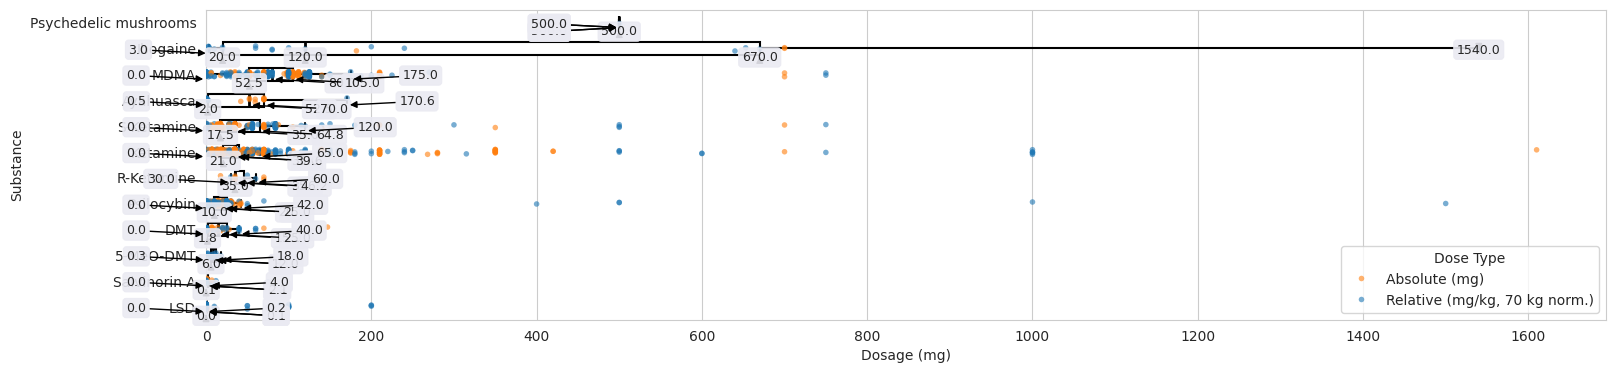

In [ ]:
make_fig()